# Simulating Neuronal Networks Using Quantum Qubits: Dravet vs. ATS Neurons

#  Real-world Implementation
Quantum neuron simulations like this have potential applications in:
Medical research: Modeling rare neuronal disorders like Dravet syndrome to understand firing irregularities
Neuroprosthetics: Designing brain-machine interfaces by predicting firing correlations
AI and Neural Networks: Exploring quantum neural networks for faster computation and probabilistic decision-making
Essentially, quantum neurons let us simulate probabilistic firing and entanglement effects that classical computers struggle to model efficiently at large scale.

# Why Classical Approaches Fail

Classical simulations struggle for these reasons:
Exponential state space:
N neurons → 2^N possible firing states

Example: 8 neurons → 256 states; 20 neurons → over 1 million states

Classical computers must store each state explicitly, which becomes infeasible quickly

Probabilistic correlations:
Neurons influence each other non-linearly
Classical probabilistic models cannot easily capture entanglement-like effects

Quantum advantage:
Using qubits, superposition naturally encodes probabilities
CNOTs naturally propagate correlations
Large networks can be modeled without explicitly storing every combination

# 4-Qubit Example
We can scale up the 4-neuron ATS/Dravet network to 4 neurons. Here’s an example approach in a Jupyter Notebook:

In [20]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi

qreg_q = QuantumRegister(156, 'q')
creg_c = ClassicalRegister(4, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.rz(-pi / 2, qreg_q[0])
circuit.rx(pi / 2, qreg_q[0])
circuit.rz(pi / 2, qreg_q[0])
circuit.rz(-pi, qreg_q[1])
circuit.cz(qreg_q[0], qreg_q[1])
circuit.rz(pi / 2, qreg_q[1])
circuit.sx(qreg_q[1])
circuit.rz(pi / 2, qreg_q[1])
circuit.rz(-pi, qreg_q[2])
circuit.cz(qreg_q[1], qreg_q[2])
circuit.rz(pi / 2, qreg_q[2])
circuit.sx(qreg_q[2])
circuit.rz(pi / 2, qreg_q[2])
circuit.rz(-pi, qreg_q[3])
circuit.cz(qreg_q[2], qreg_q[3])
circuit.rz(pi / 2, qreg_q[3])
circuit.sx(qreg_q[3])
circuit.rz(pi / 2, qreg_q[3])
circuit.measure(qreg_q[0], creg_c[0])
circuit.measure(qreg_q[1], creg_c[1])
circuit.measure(qreg_q[2], creg_c[2])
circuit.measure(qreg_q[3], creg_c[3])



# 4 Normal Unmutated Neurons 

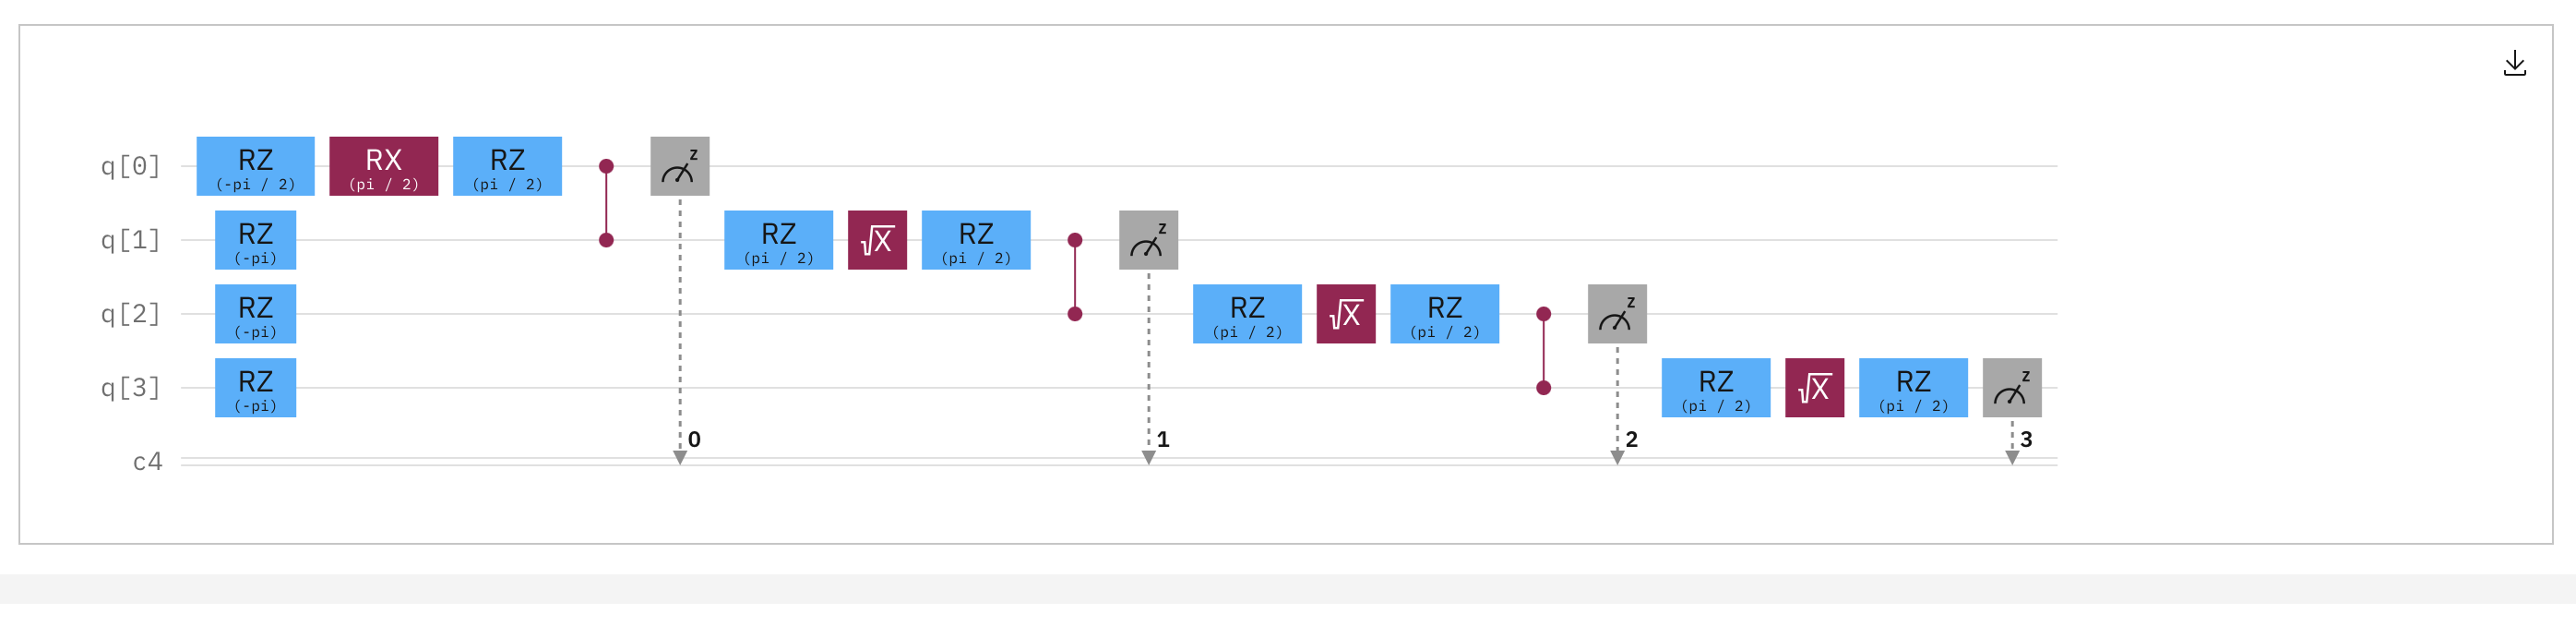


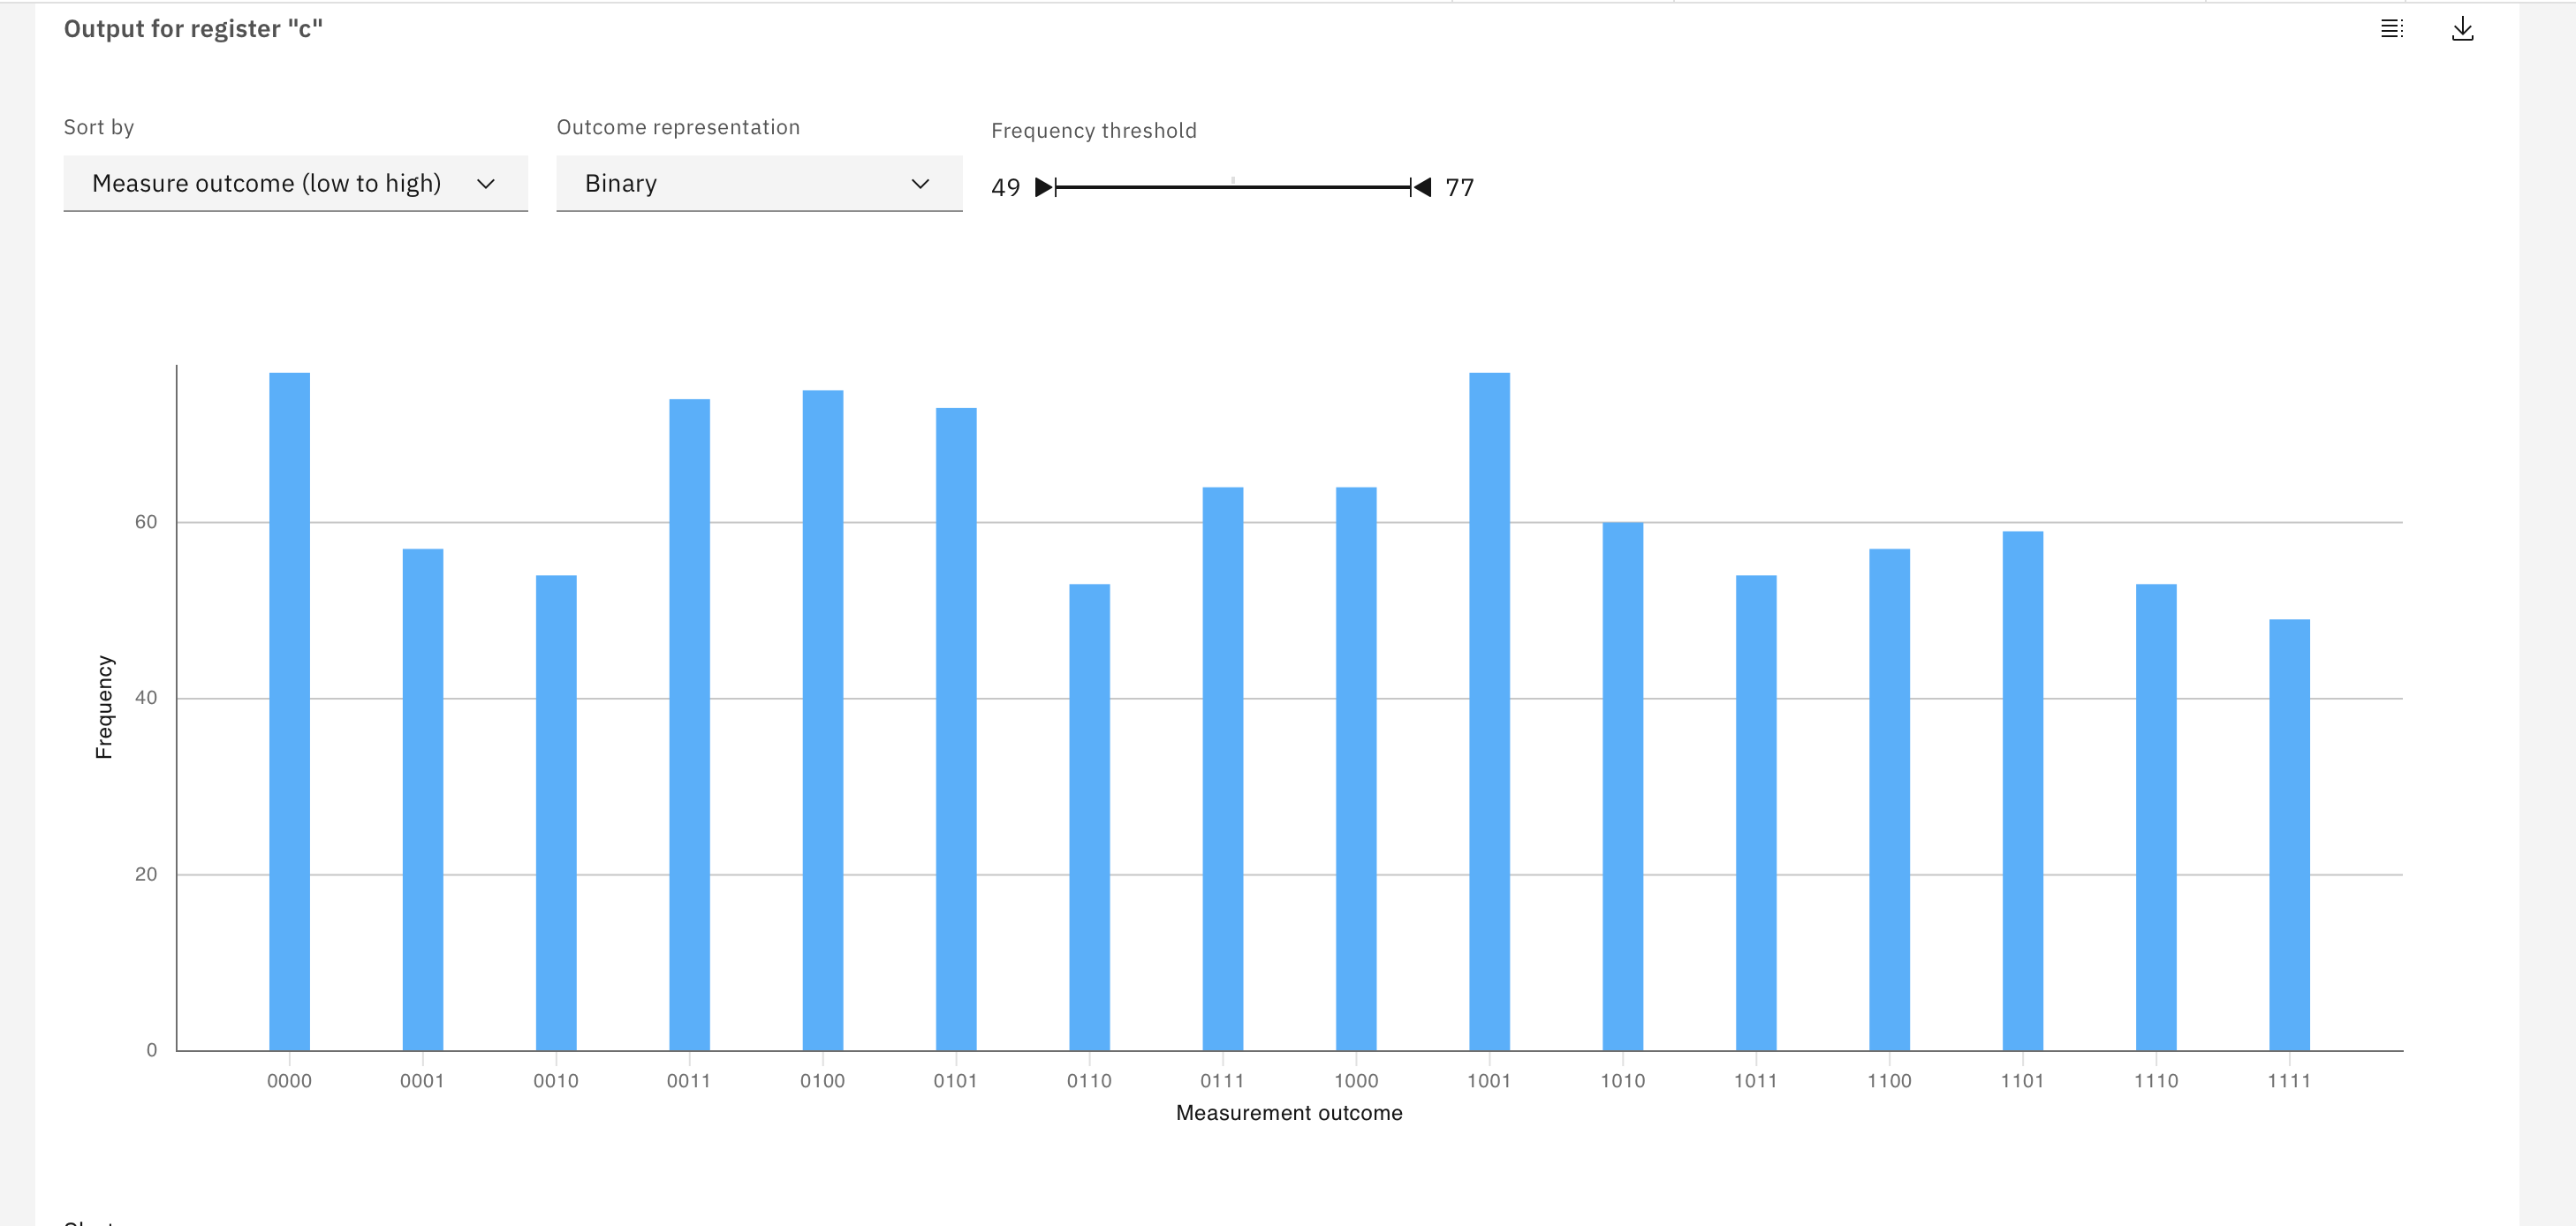
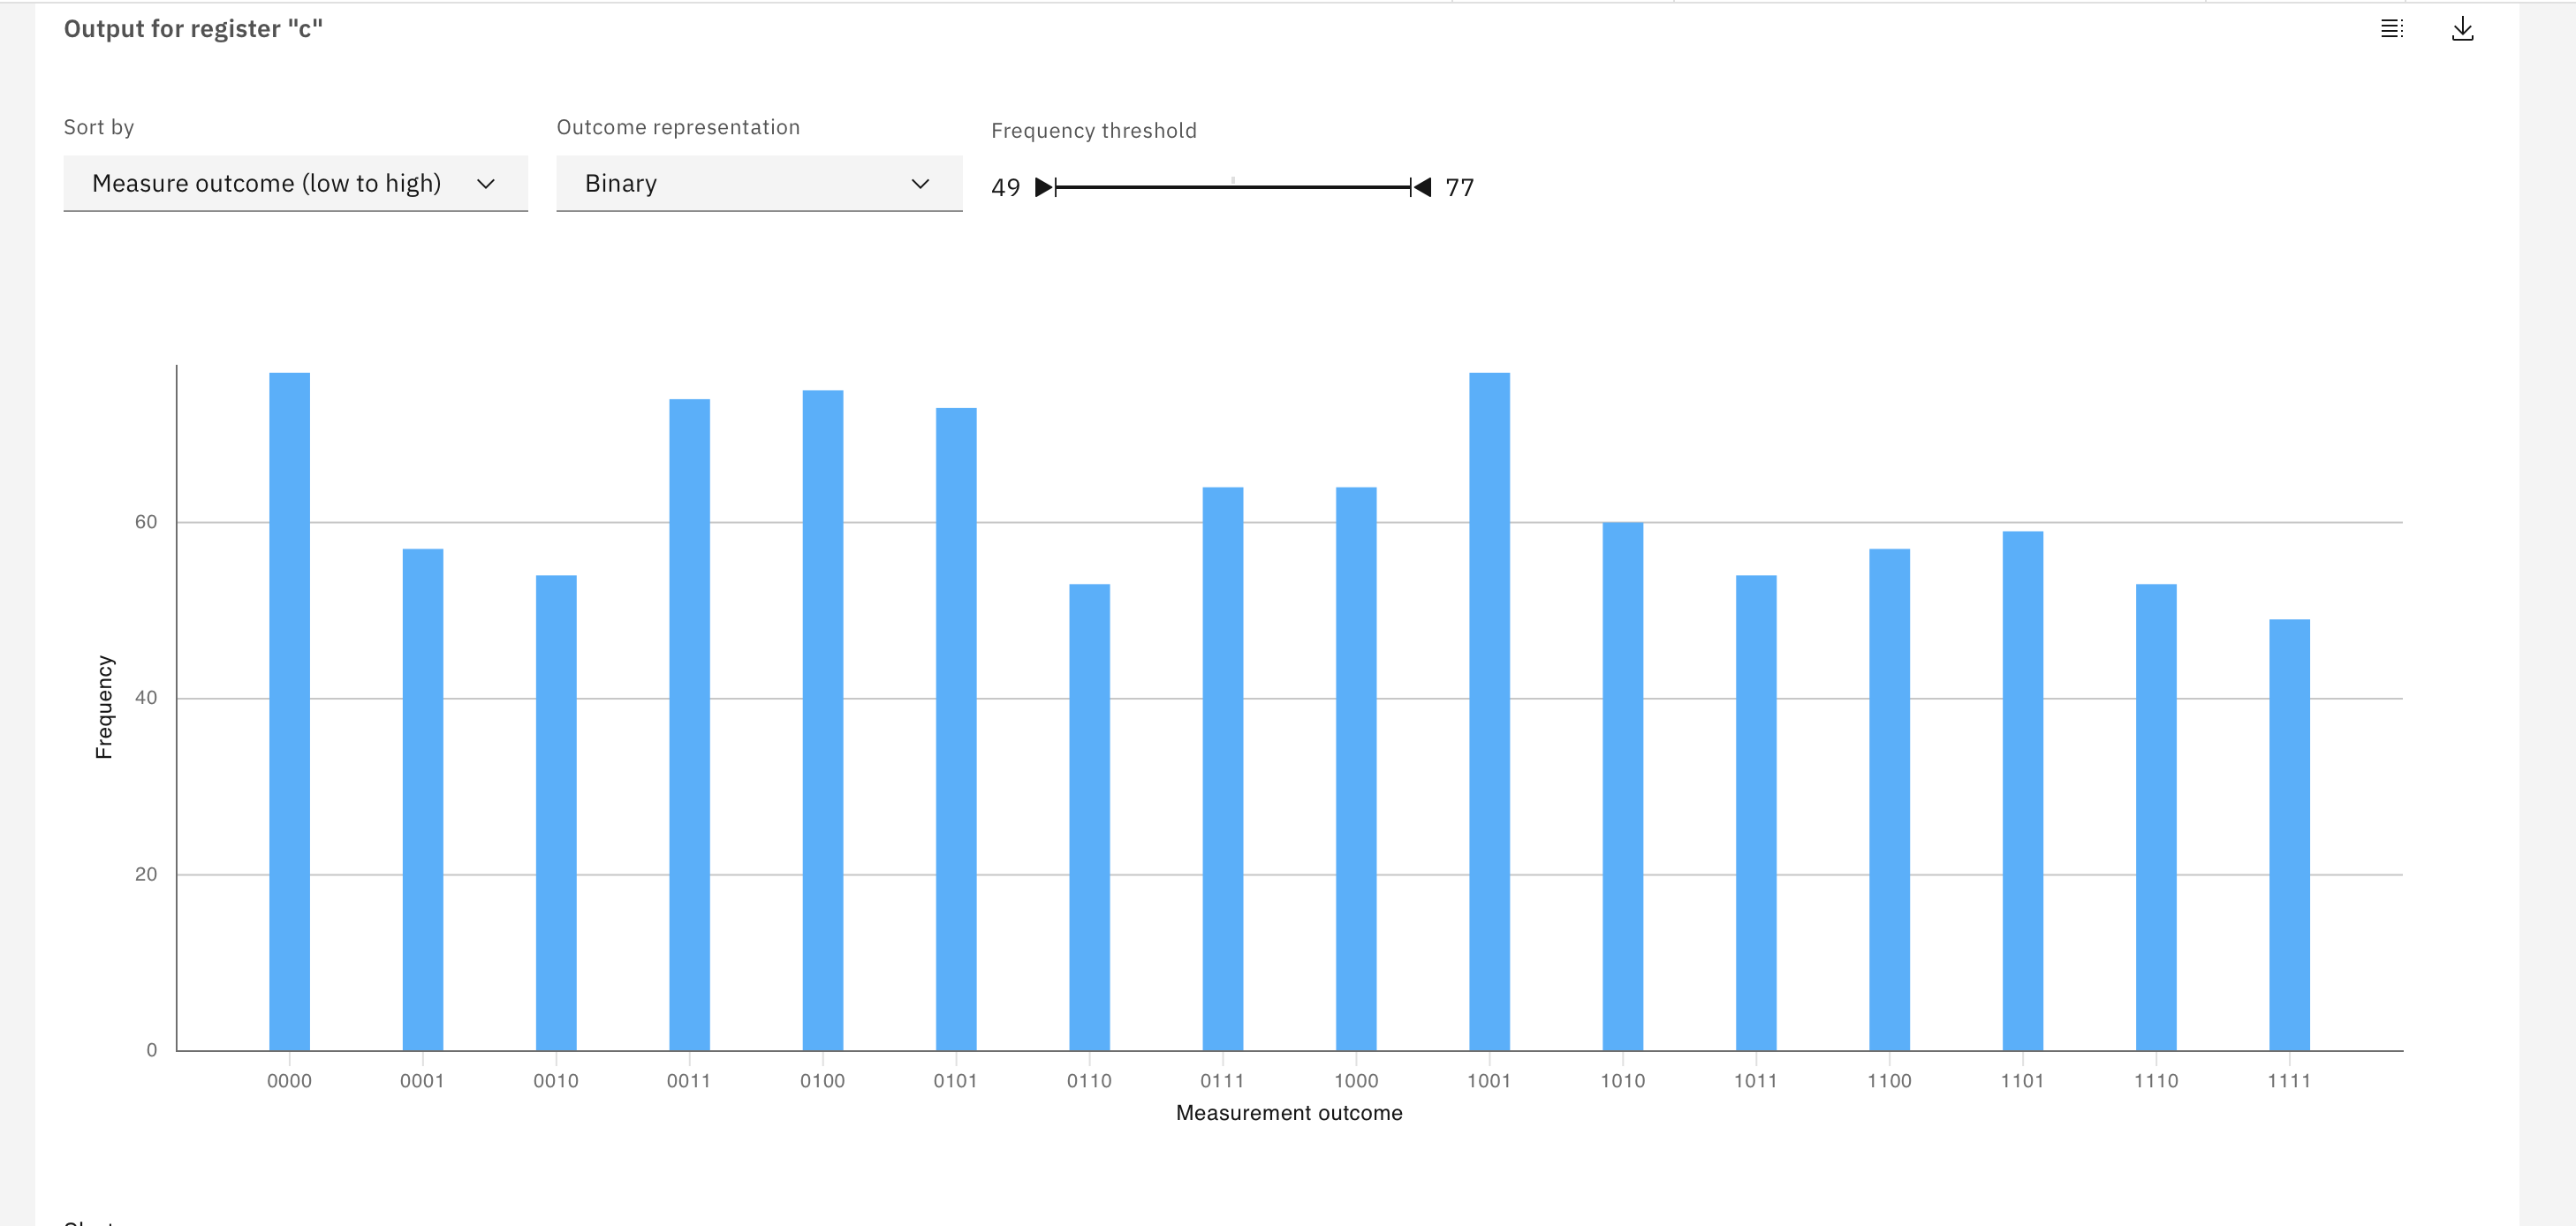

# Explanation:

Ry gates: Set baseline firing probabilities (high for Dravet, low for ATS)

CNOT chain: Propagates influence along the network

Measurement: Collapses superpositions into classical firing states

Histogram: Shows distribution of firing patterns


With 8 qubits, the network can simulate 256 possible states, which is hard to handle classically but straightforward with quantum simulation.

# Mindset Shift
Working with quantum neurons requires a new way of thinking:
Probabilistic, not deterministic:
Neurons are in superpositions → each measurement gives one possible network state
Multiple measurements are needed to get statistical firing patterns
Correlations instead of direct causation:
Firing of one neuron doesn’t guarantee the next fires; it changes probabilities
Entanglement = network connectivity:
CNOTs mimic neuron-to-neuron influence
The network behaves as a whole, not just as independent neurons
Essentially, you shift from thinking “this neuron fires → next neuron fires” to “this neuron firing alters the probabilities across the network.”